### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [5]:
!sudo apt-get install xvfb

'sudo' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'


'bash' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
%pip install gymnasium[classic_control]


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [9]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [10]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [11]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: False


In [12]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [13]:
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    action_value = 0
    for next_state in mdp.get_next_states(state, action):
        prob = mdp.get_transition_prob(state, action, next_state)
        reward = mdp.get_reward(state, action, next_state)
        action_value += prob * (reward + gamma * state_values[next_state])
    return action_value

In [14]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [15]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0

    return max(get_action_value(mdp, state_values, state, action, gamma) for action in mdp.get_possible_actions(state))
    


In [16]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

In [17]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

In [18]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [19]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [20]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [21]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None

    return max(mdp.get_possible_actions(state), key=lambda a: get_action_value(mdp, state_values, state, a, gamma))
    

In [22]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

In [23]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [24]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4919


### Frozen lake

In [25]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [26]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [27]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [28]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


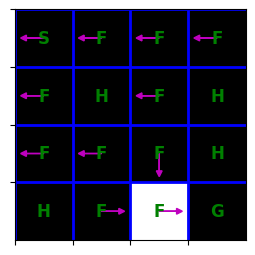

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


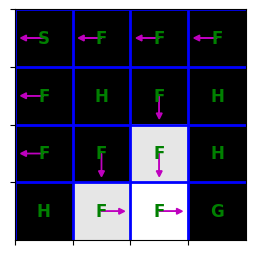

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


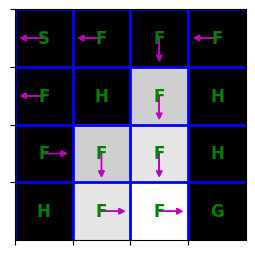

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


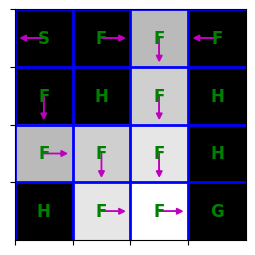

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


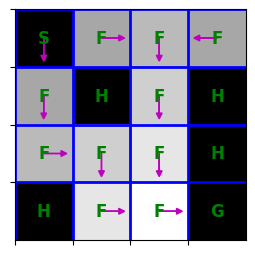

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


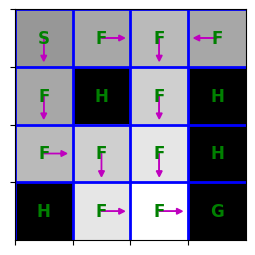

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


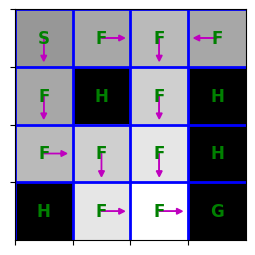

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


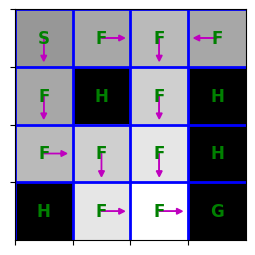

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


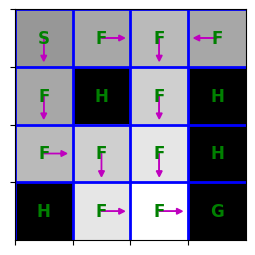

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


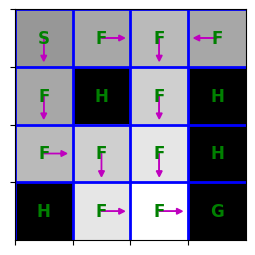

In [30]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


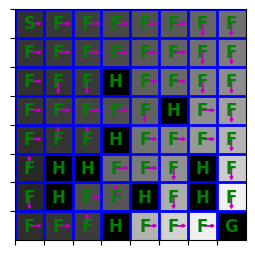

In [31]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [32]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [33]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.87
Well done!


In [34]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [35]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

**Idea:** we have 2 states, active and inactive. In active our agent will be there with p() = 1, which means if it stays there then it will get award +10 (which means good behaviour). another activity is to switch position, agent goes to inactive with p() == 1 which means if it goes there then it will be inactive and get reward -5 (ill describe idea below). And from state inactive only option - continue in inactive state with p(), basically is a cycle with no exit(terminated). As for rewards, i mentioned in state active agent recieves reward 10 for being active, but in acton swithc reward is negative (-5), and this done to make our algorithm more clever and not to make it converge from the beginning, since it is not best strategy to do for instant benefit BUT from there we can get to inactive state with p() = 1 and make our reward better because of eps i add to reward (0.1). In general according to this idea our mdp converges not in the first 50 iterations, but later and when other conditions of the problem are met. This algorithm follows idea to balance between stable but lower reward or choose lower with belief to achieve higher results after some time. Also is should say that there s no random choices here bcs of probs of states, but sometimes like here it is not needed

In [57]:
import numpy as np
from mdp import MDP
from numpy import random
import numpy as np

def test_eps(eps_value):
    transition_probs = {
        'Active': {
            'continue': {'Active': 1},
            'switch': {'Inactive': 1}
        },
        'Inactive': {'continue': {'Inactive': 1}}
    }
    rewards = {
        'Active': {
            'continue': {'Active': 10},
            'switch': {'Inactive': -5}
        },
        'Inactive': {'continue': {'Inactive': 5 + eps_value}}
    }
    
    mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
    gamma = 0.95
    state_values = {s: 0 for s in mdp.get_all_states()}
    policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                         for state in sorted(mdp.get_all_states())])
    
    for i in range(100):
        state_values = value_iteration(mdp, state_values, gamma=gamma, num_iter=1)
        new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                               for state in sorted(mdp.get_all_states())])
        n_changes = (policy != new_policy).sum()
        if i >= 50 and n_changes > 0:
            print(f"eps = {eps_value} cond satisfied: iter {i}, changes in policy: {n_changes}")
            return True
        policy = new_policy
    return False

eps = 0.0000000001
while True:
    print("check eps =", eps)
    if test_eps(eps):
        break
    eps += 0.01


check eps = 1e-10
iter    0   |   diff: 10.00000   |   V(start): 10.000 
iter    0   |   diff: 9.50000   |   V(start): 19.500 
iter    0   |   diff: 9.02500   |   V(start): 28.525 
iter    0   |   diff: 8.57375   |   V(start): 37.099 
iter    0   |   diff: 8.14506   |   V(start): 45.244 
iter    0   |   diff: 7.73781   |   V(start): 52.982 
iter    0   |   diff: 7.35092   |   V(start): 60.333 
iter    0   |   diff: 6.98337   |   V(start): 67.316 
iter    0   |   diff: 6.63420   |   V(start): 73.950 
iter    0   |   diff: 6.30249   |   V(start): 80.253 
iter    0   |   diff: 5.98737   |   V(start): 86.240 
iter    0   |   diff: 5.68800   |   V(start): 91.928 
iter    0   |   diff: 5.40360   |   V(start): 97.332 
iter    0   |   diff: 5.13342   |   V(start): 102.465 
iter    0   |   diff: 4.87675   |   V(start): 107.342 
iter    0   |   diff: 4.63291   |   V(start): 111.975 
iter    0   |   diff: 4.40127   |   V(start): 116.376 
iter    0   |   diff: 4.18120   |   V(start): 120.557 
iter

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iterateion$

*<-- Your proof here -->*

### I hope this isn't bullshit))


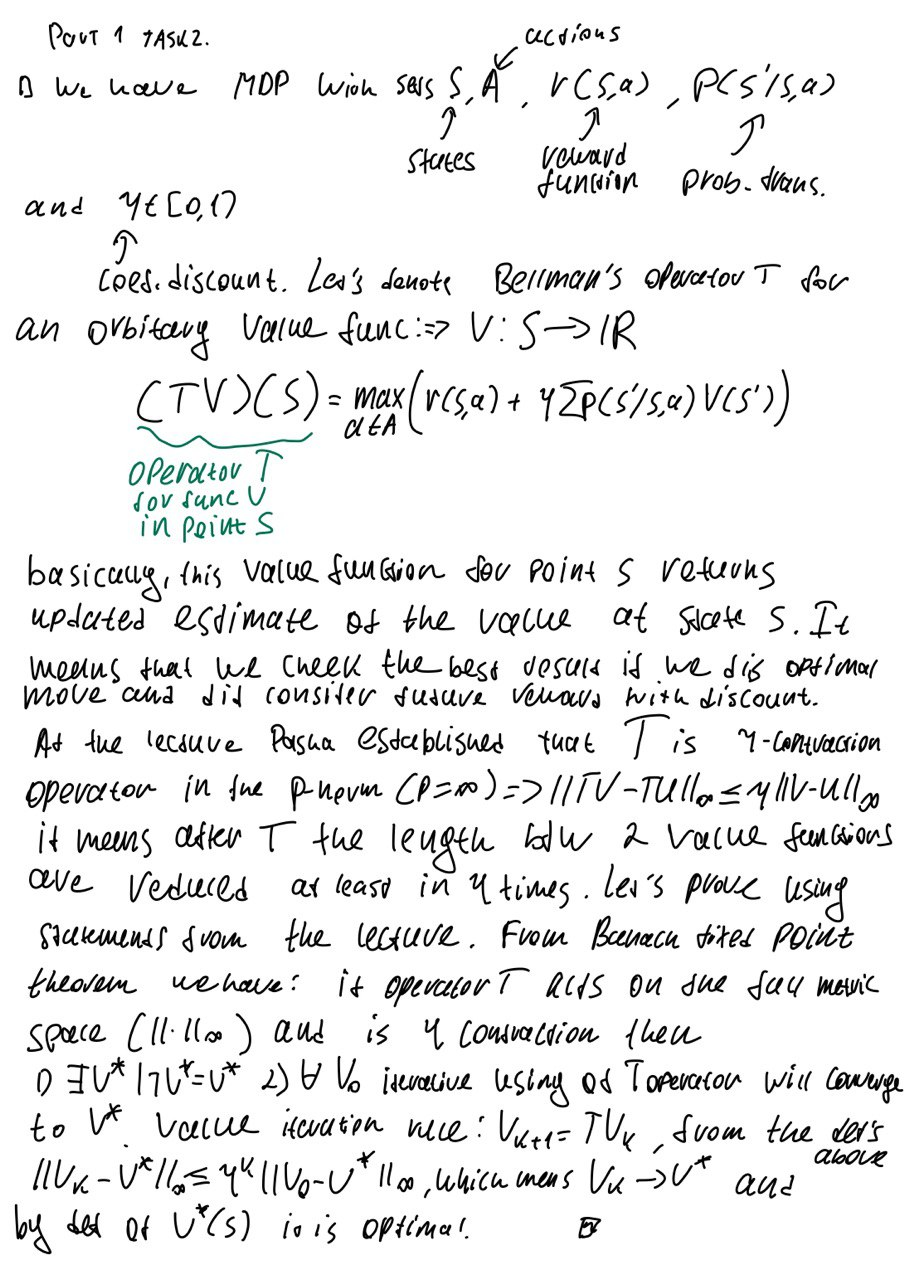

In [37]:
from PIL import Image
from IPython.display import display

img = Image.open(r'C:\Users\1\vscode-projects\Practical_RL-1\week02_value_based\task1.jpg')

display(img)

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

*<-- Your proof here -->*


### I hope this isn't bullshit))


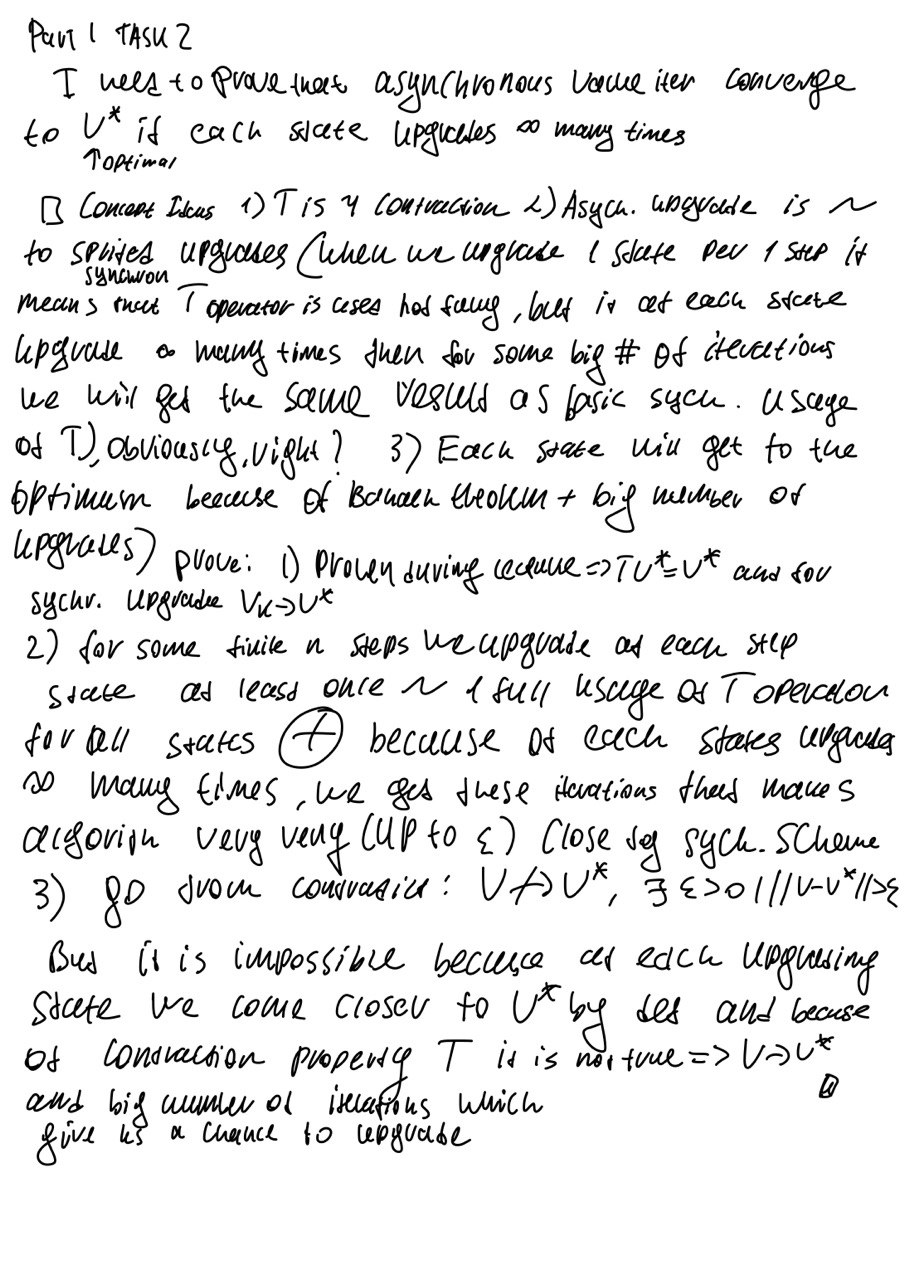

In [38]:
img = Image.open(r'C:\Users\1\vscode-projects\Practical_RL-1\week02_value_based\task2.jpg')

display(img)

# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [61]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

I will rewrite this into matrix form:

$$
V^\pi = r^\pi + \gamma P^\pi V^\pi
$$

WHERE:
- $r^\pi$ — vector of dimension $|S|$, consisting of rewards under a fixed policy $\pi$;
- $P^\pi$ — transition matrix of dimension $|S| \times |S|$ where each row corresponds to the prob of transitioning from state $s$ under $\pi(s)$.

Then (shortly): i will change the order (move to the right) and  get somethhing like

$$
(I - \gamma P^\pi) V^\pi = r^\pi.
$$

Replace for more convinience
$$
A = (I - \gamma P^\pi), \quad b = r^\pi.
$$

AAAAAAAND we get
$$
V^\pi = A^{-1} b = (I - \gamma P^\pi)^{-1} r^\pi.
$$

to solve it i need:
1.make list of all sets


2.$P^\pi$ make this matrix by taking for each row i its state s_i and p(s_i)



3.$r^\pi$ make vector for each s_i by finding expected reward under action

In [62]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    states = mdp.get_all_states()
    n = len(states)
    sorted_state_indexes = {s: i for i, s in enumerate(sorted(states))} # for stable results
    P_pi=np.zeros((n,n))
    r_pi=np.zeros(n)
    for s in states: 
        i=sorted_state_indexes[s] # index of state s in sorted order
        if mdp.is_terminal(s): # terminal state
            P_pi[i,i]=1 # no change in state
            r_pi[i]=0 # no reward
            continue
        a=policy[s] # action chosen in state s
        for next_s in states: # next_s is next state
            j=sorted_state_indexes[next_s] # index of next_s in sorted order
            P_pi[i,j]=mdp.get_transition_prob(s,a,next_s) # transition probability from s to next_s under action a
            r_pi[i]+=P_pi[i,j]*mdp.get_reward(s,a,next_s) # reward from s to next_s under action a
    v = np.linalg.inv(np.eye(n)-gamma*P_pi)@r_pi # solve linear equation
    return {s: v[sorted_state_indexes[s]] for s in sorted_state_indexes} # return as a dict {state : V^pi(state) for all states}

In [63]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(67.5525940765899), 's1': np.float64(70.98731598063037), 's2': np.float64(68.91729294682405)}


Once we've got new state values, it's time to update our policy.

In [64]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    new_policy = {}
    states = mdp.get_all_states()
    for s in states:
        if mdp.is_terminal(s):
            new_policy[s] = None # terminal state(for thenm there is no action)
        else:
            new_policy[s] = max(
                mdp.get_possible_actions(s), 
                key=lambda a: get_action_value(mdp, vpi, s, a, gamma)) # optimal action for state s (literally formula)
    return new_policy

In [65]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a0'}


__Main loop__

In [66]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    states = mdp.get_all_states()
    policy = policy or {
        s: np.random.choice(mdp.get_possible_actions(s)) if not mdp.is_terminal(s) else None 
        for s in states
    }# initialize policy with random if not given
    for i in range(num_iter):
        V_pi = compute_vpi(mdp, policy, gamma)
        state_values = V_pi
        policy = compute_new_policy(mdp, V_pi, gamma)
        if max(abs(V_pi[s] - get_new_state_value(mdp, V_pi, s, gamma))
               for s in states) < min_difference:
            break
        state_values = V_pi

    return state_values, policy

__Your PI Results__

<YOUR CODE: compare PI and VI on the MDP from def test_eps(eps_value):
, then on small & large FrozenLake
Find an MDP for which value iteration takes long to converge (1 pts) >

I will copy paste the transition probs + rewards from task 1 for more convinience 

In [67]:
def create_test_eps_mdp(eps_value):
    transition_probs = {
        'Active': {
            'continue': {'Active': 1},
            'switch': {'Inactive': 1}
        },
        'Inactive': {'continue': {'Inactive': 1}}
    }
    rewards = {
        'Active': {
            'continue': {'Active': 10},
            'switch': {'Inactive': -5}
        },
        'Inactive': {'continue': {'Inactive': 5 + eps_value}}
    }
    mdp_instance = MDP(transition_probs, rewards, initial_state='Active')
    return mdp_instance

Lets create function to compare two iterations: policy and value

In [68]:
def compare_PI_VI(mdp, gamma=0.95, min_difference=1e-5, max_iter=1000):
    # --- Value Iteration ---
    state_values = {s: 0 for s in mdp.get_all_states()} # initialize V(s) with zeros
    vi_iterations = 0 # number of iterations in value iteration
    for i in range(max_iter): 
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma)
                           for s in mdp.get_all_states()} # compute new V(s) using old V(s) 
        diff = max(abs(new_state_values[s] - state_values[s]) # compute difference between new and old V(s)
                  for s in mdp.get_all_states()) # to check convergence
        state_values = new_state_values # update V(s)
        vi_iterations += 1 
        if diff < min_difference: # check convergence (i mean i just decided to make it 1e-5, why not)
            break
    final_values_vi = state_values.copy() # final V(s) after value iteration
    
    # --- Policy Iteration ---
    # Just usin existing policy_iteration function, so no comments here
    final_values_pi, final_policy = policy_iteration(mdp, gamma=gamma, 
                                                   num_iter=max_iter,
                                                   min_difference=min_difference)
    return {
        'vi': {'iterations': vi_iterations, 'state_values': final_values_vi},
        'pi': {'iterations': None, 'state_values': final_values_pi, 'policy': final_policy}
    }

So lets check

In [69]:
eps_value = 1e-10
mdp_test = create_test_eps_mdp(eps_value)
result_test = compare_PI_VI(mdp_test)
print("Compare PI and VI on my MDP from task1:")
print("Value Iteration: iterations =", result_test['vi']['iterations'])
print("Final V(s) VI:", result_test['vi']['state_values'])
print("Final V(s) PI:", result_test['pi']['state_values'])
print("Final PI policy:", result_test['pi']['policy'])

Compare PI and VI on my MDP from task1:
Value Iteration: iterations = 271
Final V(s) VI: {'Active': 199.99981629243982, 'Inactive': 99.99990814821994}
Final V(s) PI: {'Active': np.float64(199.99999999999983), 'Inactive': np.float64(100.00000000199991)}
Final PI policy: {'Active': 'continue', 'Inactive': 'continue'}


So we can see that we get +- the same results optimal functins and policy for different MDP. Maybe this is because of the mdp i made, but in general it is look OK. I wanna add that policty iteration in general should be faster than value iteration since PI converges faster.

In [70]:
mdp_small = FrozenLakeEnv(slip_chance=0)  
result_small = compare_PI_VI(mdp_small, gamma=0.9)
print("\nCompare FrozenLake 4x4:")
print("VI: iterations =", result_small['vi']['iterations'])
print("Final V(s) VI:", result_small['vi']['state_values'])
print("Final policy PI:", result_small['pi']['policy'])


Compare FrozenLake 4x4:
VI: iterations = 7
Final V(s) VI: {(0, 0): 0.5904900000000002, (0, 1): 0.6561000000000001, (0, 2): 0.7290000000000001, (0, 3): 0.6561000000000001, (1, 0): 0.6561000000000001, (1, 1): 0, (1, 2): 0.81, (1, 3): 0, (2, 0): 0.7290000000000001, (2, 1): 0.81, (2, 2): 0.9, (2, 3): 0, (3, 0): 0, (3, 1): 0.9, (3, 2): 1.0, (3, 3): 0}
Final policy PI: {(0, 0): 'down', (0, 1): 'right', (0, 2): 'down', (0, 3): 'left', (1, 0): 'down', (1, 1): None, (1, 2): 'down', (1, 3): None, (2, 0): 'right', (2, 1): 'down', (2, 2): 'down', (2, 3): None, (3, 0): None, (3, 1): 'right', (3, 2): 'right', (3, 3): None}


Here we see that VI converged in 7 iters which is pretty obvious since map is small. 

In [71]:
mdp_large = FrozenLakeEnv(slip_chance=0.1, map_name='8x8') 
result_large = compare_PI_VI(mdp_large, gamma=0.9)
print("\nCompare FrozenLake 88:")
print("VI: iterations =", result_large['vi']['iterations'])
print("Final V(s) VI:", result_large['vi']['state_values'])
print("Final policy PI:", result_large['pi']['policy'])


Compare FrozenLake 88:
VI: iterations = 26
Final V(s) VI: {(0, 0): 0.1981662728994766, (0, 1): 0.22234368819912914, (0, 2): 0.24939356666255505, (0, 3): 0.2796303960927743, (0, 4): 0.31337218487470453, (0, 5): 0.3501900426518515, (0, 6): 0.391187696567162, (0, 7): 0.43410192524429003, (1, 0): 0.20337201853339718, (1, 1): 0.22955531855008068, (1, 2): 0.25934258586731945, (1, 3): 0.2936808151181706, (1, 4): 0.3470339236983081, (1, 5): 0.3904326203131956, (1, 6): 0.4393760016648166, (1, 7): 0.4900788811979059, (2, 0): 0.18923960304960263, (2, 1): 0.21072515241137724, (2, 2): 0.2275230200650764, (2, 3): 0, (2, 4): 0.3707059289183007, (2, 5): 0.41732245205610324, (2, 6): 0.4935222041894918, (2, 7): 0.5533992737919408, (3, 0): 0.20890849679830137, (3, 1): 0.2370014059955986, (3, 2): 0.269185704121207, (3, 3): 0.30704795044119104, (3, 4): 0.3790715443914942, (3, 5): 0, (3, 6): 0.5553576873682122, (3, 7): 0.6250466757547943, (4, 0): 0.18715485682998667, (4, 1): 0.21063114040095057, (4, 2): 0.

Here we see that it converged in 26 iters which is also obvious since map is large

General concl: Both methods give us one important and obvious poin: mdp do matter. I mean we tried some methods and becuase of mdp i have (its about 1 task) i got those results. So in first case there is almost no difference while in second case we have differ because of the size of the map (longer game)

As for long converging MDP: i'll try to make chain s_0 -> s_n-1, where s_0 -> s_n-2 have no reward and s_n-1 is cyclic and have reward. Like this

    For each state s_i (i < n-1):
       action  leads with probability p to s_i (selfloop)
        and with probability 1-p to s_i+1 with no reward
    For the last state s_n-1:
       action leads to selfloop with reward 1

In [72]:
def generate_chain_mdp_with_slow_transitions(n, p=0.99):
    transition_probs = {}
    rewards = {}
    for i in range(n):
        s = f's{i}'
        if i < n - 1:
            next_s = f's{i+1}' # next state
            transition_probs[s] = {'a': {s: p, next_s: 1 - p}} # transition probabilities from s to next_s under action a
            rewards[s] = {'a': {s: 0.0, next_s: 0.0}} # reward from s to next_s under action a
        else:
            transition_probs[s] = {'a': {s: 1.0}} # terminal state
            rewards[s] = {'a': {s: 1.0}}
    return MDP(transition_probs, rewards, initial_state='s0')

In [73]:
def evaluate_mdp_convergence_steps(mdp, gamma=0.99, min_difference=1e-5, max_iter=5000):
    state_values = {s: 0 for s in mdp.get_all_states()}
    for i in range(max_iter):
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma)
                            for s in mdp.get_all_states()}
        diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
        state_values = new_state_values
        if diff < min_difference:
            return i + 1, state_values
    return max_iter, state_values


In [74]:
n = 1000       
gamma = 0.99     
p = 0.99         

mdp_slow = generate_chain_mdp_with_slow_transitions(n, p)

mdp_iterations_count, _ = evaluate_mdp_convergence_steps(mdp_slow)
print("\nSlow Chain MDP ({} states)".format(n))
print("Value Iteration converged over iterations =", mdp_iterations_count)


Slow Chain MDP (1000 states)
Value Iteration converged over iterations = 1147


So, in this idea n(number of states) does not matter becuse criteria of converg is diff in max_s |v_new-v| for all states but not the number of states. TBH idk was it legal to do so, but anyway it follows the task so..

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

*<-- Your proof here -->*



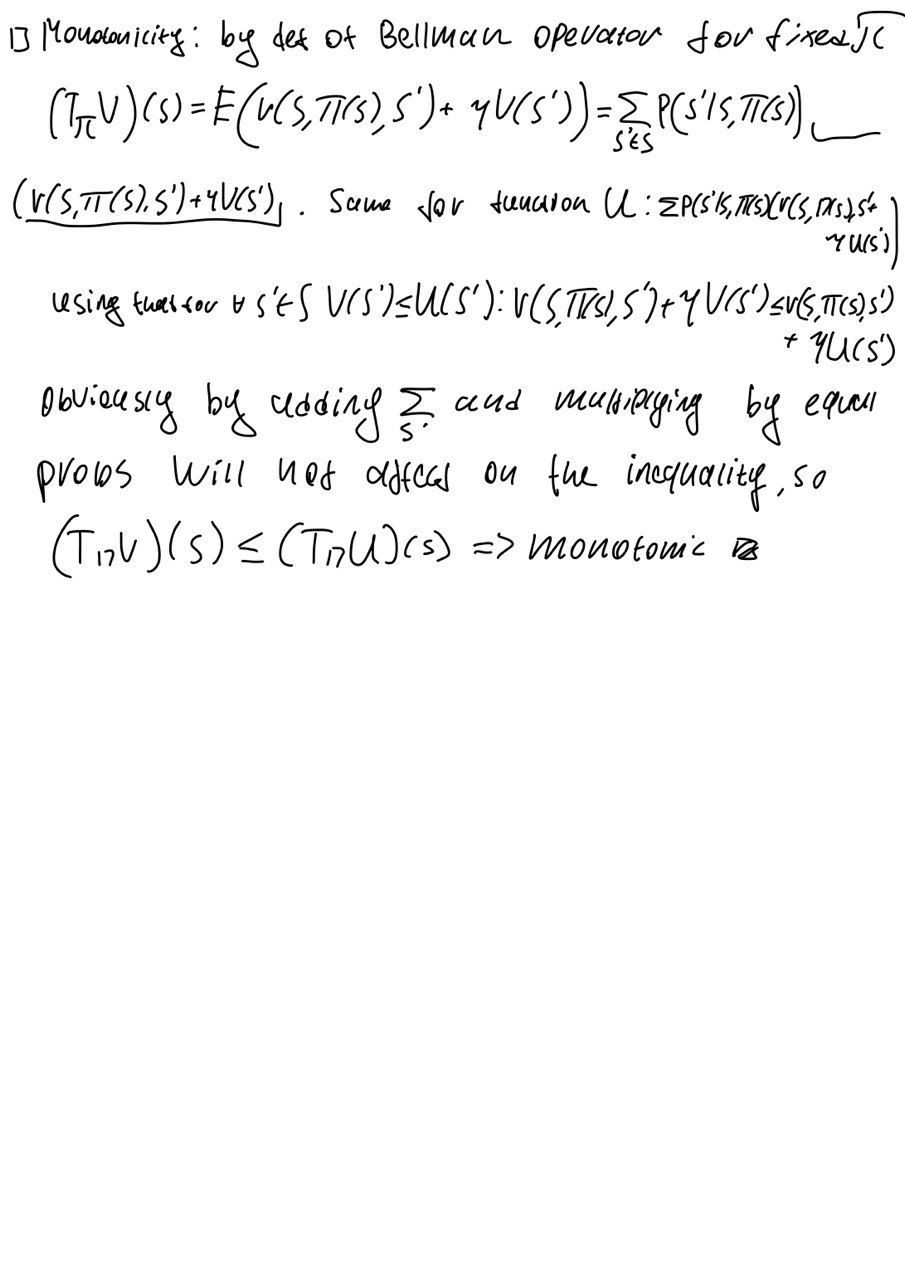

In [75]:
img = Image.open(r'C:\Users\1\vscode-projects\Practical_RL-1\week02_value_based\task3.jpg')

display(img)

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

*<-- Your proof here -->*

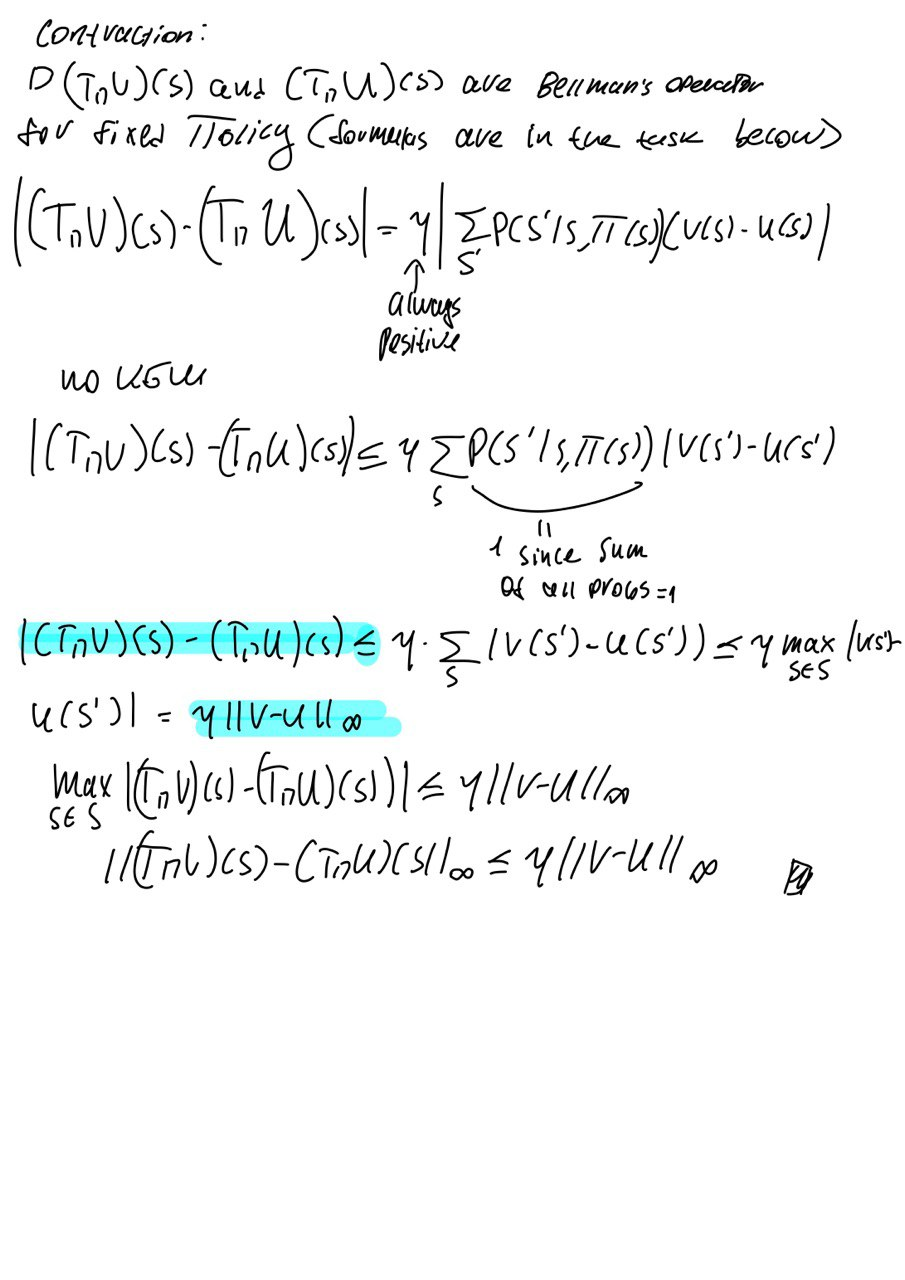

In [76]:
img = Image.open(r'C:\Users\1\vscode-projects\Practical_RL-1\week02_value_based\task4.jpg')

display(img)



#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

*<-- Your proof here -->* i guess my proof is bullshit..

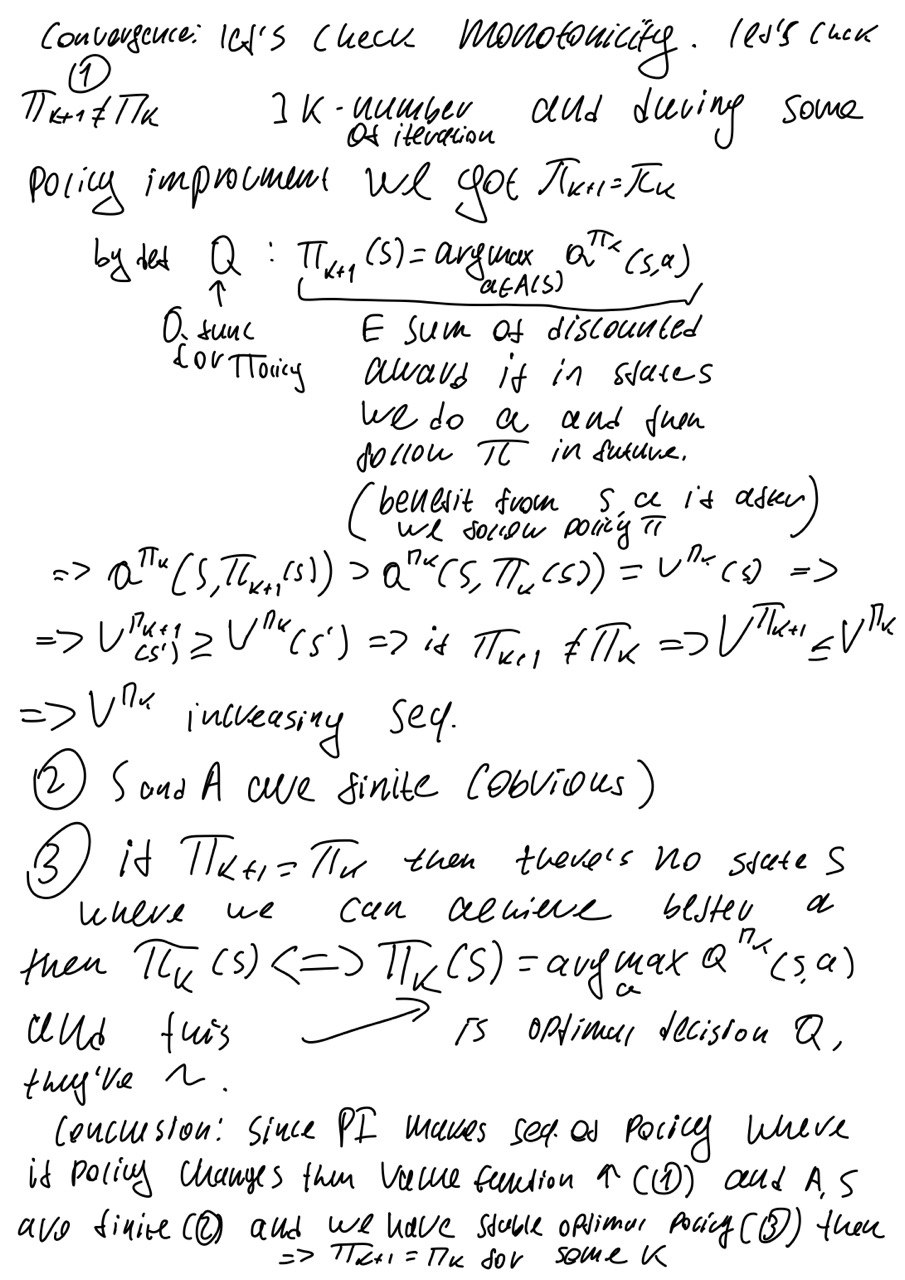

In [77]:
img = Image.open(r'C:\Users\1\vscode-projects\Practical_RL-1\week02_value_based\task5.jpg')

display(img)